# Patient and Conditions — Overall Overview: understand breakdown

Diagnostic panels for the DEG analysis cohort. Two groups:
- **Slide 1 (main overview)**: sampling completeness, cell type composition spread, clinical covariates
- **Slide 2 (DEG-readiness, backup)**: pseudobulk QC, PCA design-matrix check, batch confounding, per-sample QC

In [1]:
DATA_PATH  = "/vol/disk/ubuntu/master_practicum_cytokines/repo/Mapra_Cytokines/data/data_for_practicum_post_integration.h5ad"
OUTPUT_DIR = "/vol/disk/ubuntu/master_practicum_cytokines/lisa/cohort_overview_qc"
CELL_TYPE_COL = "cell_type_Scanorama"

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.sparse import issparse
from scipy import stats as sstats
from sklearn.decomposition import PCA
import scanpy as sc

os.makedirs(OUTPUT_DIR, exist_ok=True)
sc.settings.verbosity = 1
np.random.seed(0)

adata = sc.read_h5ad(DATA_PATH)

def parse_timepoint(display_name):
    s = str(display_name)
    if "." not in s:
        return "TP0M"
    return f"TP{s.split('.')[-1]}M"

adata.obs["timepoint"] = adata.obs["display_name"].apply(parse_timepoint)

condition_map = {
    "acs_w_o_infection":         "ACS_sterile",
    "acs_w_infection":           "ACS_infection",
    "acs_subacute":              "ACS_subacute",
    "ccs":                       "CCS",
    "vollstaendiger_ausschluss": "non-CCS",
    "koronarsklerose":           "Sclerosis",
}
adata.obs["condition"] = adata.obs["classification"].map(condition_map)
adata.obs["is_acs"] = adata.obs["condition"].str.startswith("ACS")
adata.obs["patient_num"] = adata.obs["display_name"].apply(lambda x: str(x).split(".")[0])

# Globally-unique patient id: scoped by ACS vs Control recruitment pool, since the
# two pools were numbered independently and collide as raw strings (e.g. "2" means
# a different physical patient in ACS vs. CCS).
adata.obs["macro_group"] = np.where(adata.obs["is_acs"], "ACS", "Control")
adata.obs["patient_id"] = adata.obs["macro_group"] + "_" + adata.obs["patient_num"]

condition_order = ["ACS_sterile", "ACS_infection", "ACS_subacute", "CCS", "non-CCS", "Sclerosis"]
colors_cond = {
    "ACS_sterile":   "#d62728",
    "ACS_infection": "#ff7f0e",
    "ACS_subacute":  "#e377c2",
    "CCS":           "#1f77b4",
    "non-CCS":       "#2ca02c",
    "Sclerosis":     "#17becf",
}

print(f"Cells: {adata.n_obs:,}   Patients: {adata.obs['patient_id'].nunique()}   Samples: {adata.obs['display_name'].nunique()}")

Cells: 109,504   Patients: 61   Samples: 119


# Slide 1 — Main overview

## Panel 1 — Patient x timepoint matrix

One row per ACS patient (all subtypes pooled — sterile/infection/subacute — since this is about *sampling*, not disease classification), columns TP1M-TP4M, filled if a sample exists. Rows sorted by completeness. Companion bar: how many patients have 1, 2, 3, 4 timepoints.

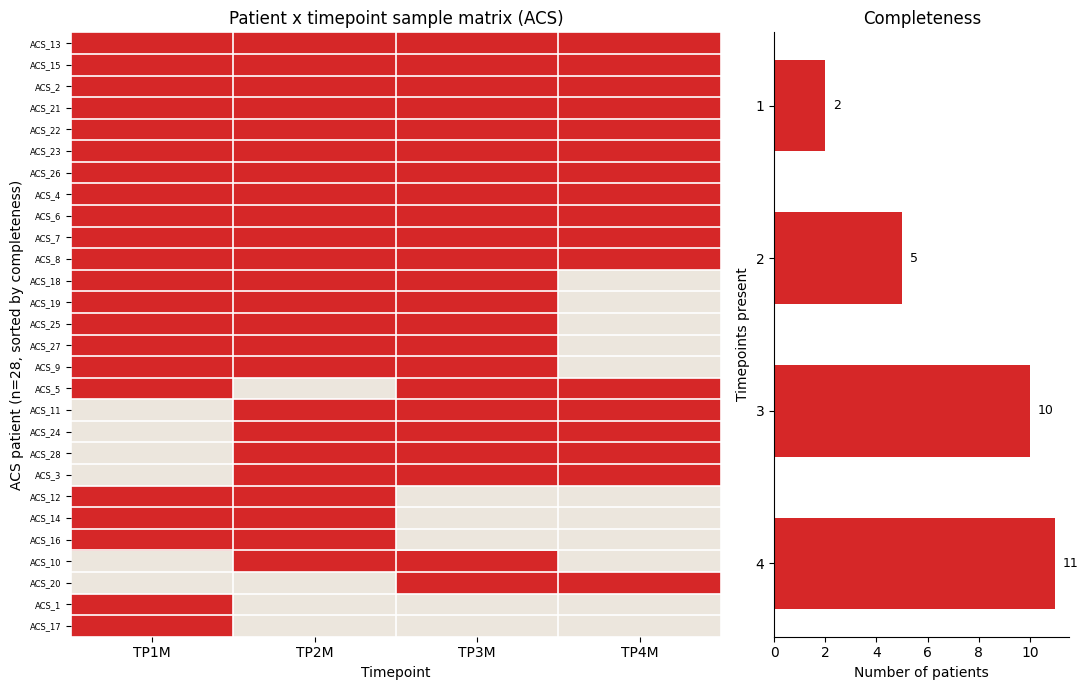

11 of 28 ACS patients have all 4 timepoints
n_timepoints
4    11
3    10
2     5
1     2


In [2]:
acs_obs = adata.obs.loc[adata.obs["is_acs"], ["patient_id", "timepoint", "display_name"]].drop_duplicates("display_name")

timepoints_order = ["TP1M", "TP2M", "TP3M", "TP4M"]
presence = (
    acs_obs.assign(present=1)
    .pivot_table(index="patient_id", columns="timepoint", values="present", fill_value=0)
    .reindex(columns=timepoints_order, fill_value=0)
)
presence["n_timepoints"] = presence[timepoints_order].sum(axis=1).astype(int)
presence = presence.sort_values(["n_timepoints"] + timepoints_order, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 7), gridspec_kw={"width_ratios": [2.2, 1]})

ax = axes[0]
mat = presence[timepoints_order].values
cmap = mcolors.ListedColormap(["#ece6dd", "#d62728"])
ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(timepoints_order)))
ax.set_xticklabels(timepoints_order, fontsize=10)
ax.set_yticks(range(len(presence)))
ax.set_yticklabels(presence.index, fontsize=6)
ax.set_xlabel("Timepoint")
ax.set_ylabel(f"ACS patient (n={len(presence)}, sorted by completeness)")
ax.set_title("Patient x timepoint sample matrix (ACS)", fontsize=12)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(timepoints_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(presence), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

ax2 = axes[1]
completeness_counts = presence["n_timepoints"].value_counts().reindex([1, 2, 3, 4], fill_value=0)
bars = ax2.barh(completeness_counts.index.astype(str), completeness_counts.values, color="#d62728", height=0.6)
ax2.set_xlabel("Number of patients")
ax2.set_ylabel("Timepoints present")
ax2.set_title("Completeness", fontsize=12)
ax2.invert_yaxis()
ax2.spines[["top", "right"]].set_visible(False)
for b, v in zip(bars, completeness_counts.values):
    ax2.text(v + 0.3, b.get_y() + b.get_height() / 2, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel1_patient_timepoint_matrix.png"), bbox_inches="tight", dpi=150)
plt.show()

print(f"{(presence['n_timepoints'] == 4).sum()} of {len(presence)} ACS patients have all 4 timepoints")
print(presence["n_timepoints"].value_counts().sort_index(ascending=False).to_string())

## Panel 2 — Cell type composition per sample (boxplots)

Per-sample proportions (not a pooled stacked bar), so spread within a condition is visible and no single large sample can dominate. ACS is split by timepoint to expose composition shifts over recovery, which are both a finding and a potential DEG confounder.

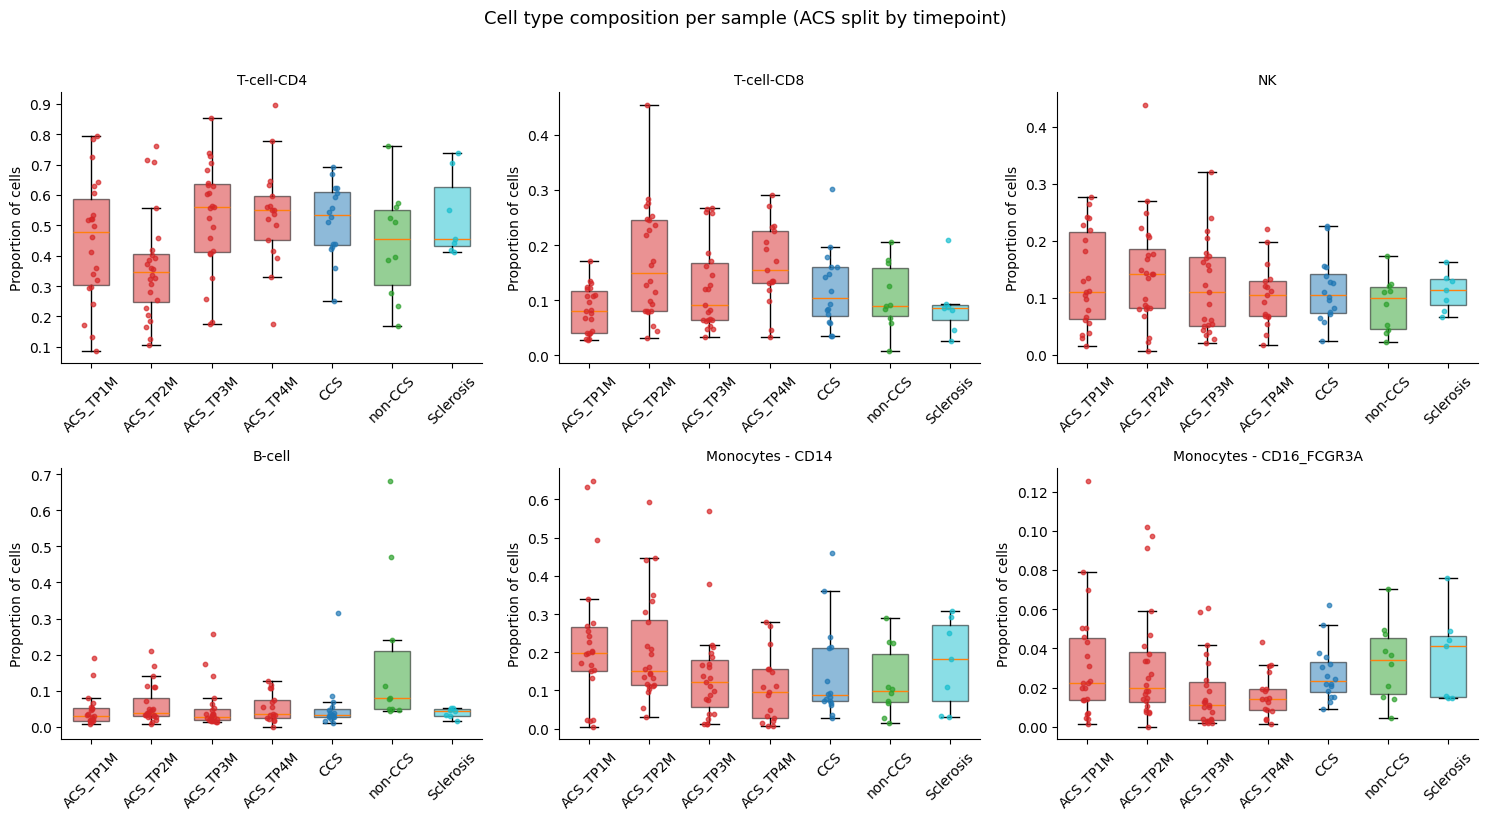

In [3]:
ct_order = [
    "T-cell-CD4", "T-cell-CD8", "NK", "B-cell",
    "Monocytes - CD14", "Monocytes - CD16_FCGR3A",
    "Dendritic", "Plasma Blast", "Progenitor", "Megakaryocytes", "Other"
]

comp = (
    adata.obs.groupby(["display_name", CELL_TYPE_COL], observed=True)
    .size()
    .unstack(fill_value=0)
)
comp = comp.div(comp.sum(axis=1), axis=0)

sample_meta = adata.obs.drop_duplicates("display_name").set_index("display_name")[["condition", "timepoint"]]
comp = comp.join(sample_meta)

comp["group"] = np.where(
    comp["condition"].astype(str).str.startswith("ACS"),
    "ACS_" + comp["timepoint"].astype(str),
    comp["condition"].astype(str),
)
group_order = ["ACS_TP1M", "ACS_TP2M", "ACS_TP3M", "ACS_TP4M", "CCS", "non-CCS", "Sclerosis"]
comp = comp[comp["group"].isin(group_order)]

top_cts = [c for c in ct_order if c in comp.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, ct in zip(axes, top_cts):
    data = [comp.loc[comp["group"] == g, ct].values for g in group_order]
    bp = ax.boxplot(data, tick_labels=group_order, patch_artist=True, showfliers=False, widths=0.6)
    for patch, g in zip(bp["boxes"], group_order):
        base = "ACS_sterile" if g.startswith("ACS") else g
        patch.set_facecolor(colors_cond.get(base, "grey"))
        patch.set_alpha(0.5)
    for i, g in enumerate(group_order):
        y = comp.loc[comp["group"] == g, ct].values
        x = np.random.normal(i + 1, 0.05, size=len(y))
        base = "ACS_sterile" if g.startswith("ACS") else g
        ax.scatter(x, y, s=10, color=colors_cond.get(base, "grey"), alpha=0.7, zorder=3)
    ax.set_title(ct, fontsize=10)
    ax.set_ylabel("Proportion of cells")
    ax.tick_params(axis="x", rotation=45)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(top_cts):]:
    ax.set_visible(False)

fig.suptitle("Cell type composition per sample (ACS split by timepoint)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel2_composition_per_sample.png"), bbox_inches="tight", dpi=150)
plt.show()

## Panel 3 — Covariates by condition (age, sex, BMI, medications, comorbidities)

In [4]:
covariate_candidates = ["age", "sex", "bmi", "statin", "diabetes", "medication", "comorbidity"]
covariate_cols_present = [c for c in covariate_candidates if c in adata.obs.columns]

print("Covariate columns found in adata.obs:", covariate_cols_present if covariate_cols_present else "NONE")
print()
if not covariate_cols_present:
    print("NOT AVAILABLE in this dataset: no age, sex, BMI, medication, or comorbidity")
    print("column exists anywhere in adata.obs, and no separate clinical metadata table")
    print("was found in the project directory (checked all .csv files across the repo).")
    print()
    print("This panel cannot be built from data currently available. It would require a")
    print("clinical covariates table (e.g. from the original Munich cohort clinical")
    print("database / Pekayvaz et al. Supplementary Table 1) joined on patient_id.")
    print()
    print("This is a real gap: if e.g. non-CCS controls are systematically younger than")
    print("ACS patients, that age difference confounds every DEG comparison in this")
    print("notebook, since immune gene expression shifts substantially with age.")

Covariate columns found in adata.obs: NONE

NOT AVAILABLE in this dataset: no age, sex, BMI, medication, or comorbidity
column exists anywhere in adata.obs, and no separate clinical metadata table
was found in the project directory (checked all .csv files across the repo).

This panel cannot be built from data currently available. It would require a
clinical covariates table (e.g. from the original Munich cohort clinical
database / Pekayvaz et al. Supplementary Table 1) joined on patient_id.

This is a real gap: if e.g. non-CCS controls are systematically younger than
ACS patients, that age difference confounds every DEG comparison in this
notebook, since immune gene expression shifts substantially with age.


# Slide 2 — DEG readiness (backup)

## Panel 4 — Pseudobulk cell/count filter (decoupler-style)

`psbulk_cells` vs `psbulk_counts` per (sample, cell type) pseudobulk unit, faceted by cell type, with the 10-cell / 1000-count thresholds drawn in. Followed by the count of surviving pseudobulks per cell type per condition after QC — this is the real sample-size table for the DEG analysis.

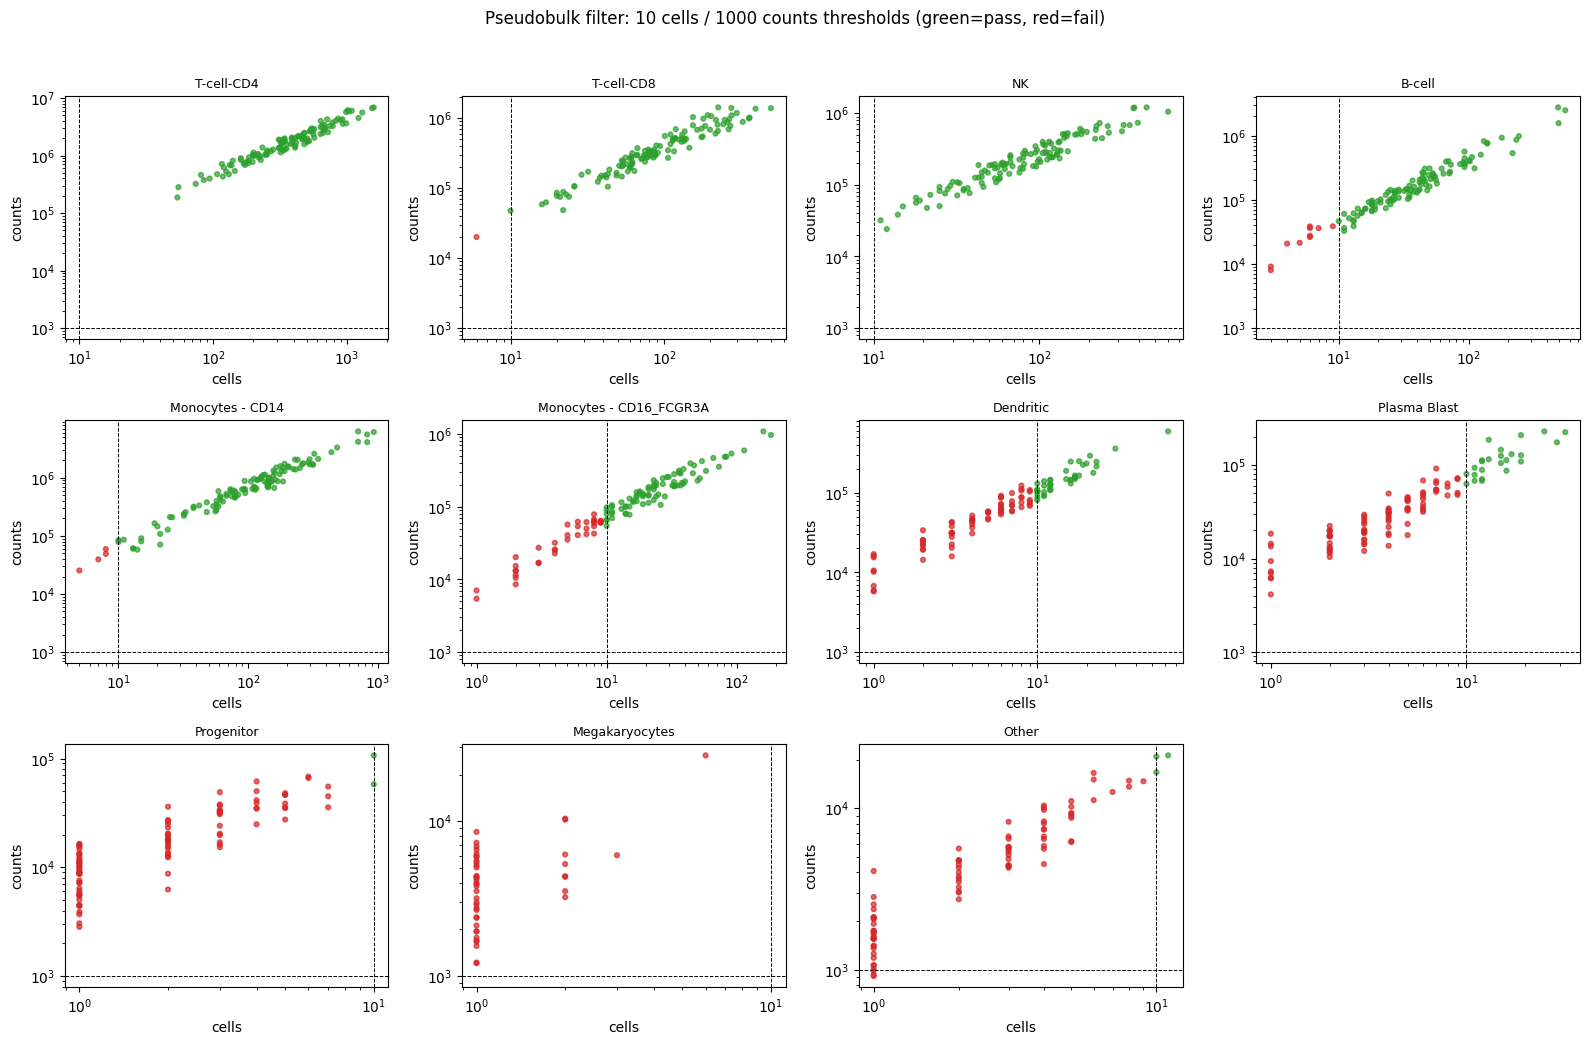

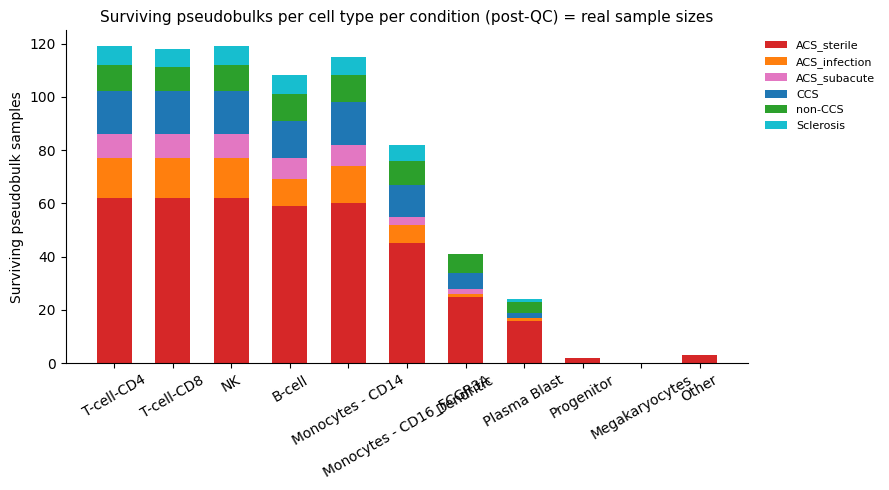

condition,ACS_sterile,ACS_infection,ACS_subacute,CCS,non-CCS,Sclerosis
cell_type,,,,,,
T-cell-CD4,62.0,15.0,9.0,16.0,10.0,7.0
T-cell-CD8,62.0,15.0,9.0,16.0,9.0,7.0
NK,62.0,15.0,9.0,16.0,10.0,7.0
B-cell,59.0,10.0,8.0,14.0,10.0,7.0
Monocytes - CD14,60.0,14.0,8.0,16.0,10.0,7.0
Monocytes - CD16_FCGR3A,45.0,7.0,3.0,12.0,9.0,6.0
Dendritic,25.0,1.0,2.0,6.0,7.0,0.0
Plasma Blast,16.0,1.0,0.0,2.0,4.0,1.0
Progenitor,2.0,0.0,0.0,0.0,0.0,0.0


In [5]:
MIN_CELLS = 10
MIN_COUNTS = 1000

psbulk_rows = []
for (sample, ct), idx in adata.obs.groupby(["display_name", CELL_TYPE_COL], observed=True).groups.items():
    n_cells = len(idx)
    total_counts = adata.obs.loc[idx, "total_counts"].sum()
    condition = adata.obs.loc[idx[0], "condition"]
    psbulk_rows.append({"sample": sample, "cell_type": ct, "psbulk_cells": n_cells,
                         "psbulk_counts": total_counts, "condition": condition})
psbulk_qc = pd.DataFrame(psbulk_rows)
psbulk_qc["passes"] = (psbulk_qc["psbulk_cells"] >= MIN_CELLS) & (psbulk_qc["psbulk_counts"] >= MIN_COUNTS)

cts_present = [c for c in ct_order if c in psbulk_qc["cell_type"].unique()]
ncols = 4
nrows = int(np.ceil(len(cts_present) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.4 * nrows))
axes = np.array(axes).flatten()

for ax, ct in zip(axes, cts_present):
    sub = psbulk_qc[psbulk_qc["cell_type"] == ct]
    colors = sub["passes"].map({True: "#2ca02c", False: "#d62728"})
    ax.scatter(sub["psbulk_cells"], sub["psbulk_counts"], c=colors, s=12, alpha=0.7)
    ax.axvline(MIN_CELLS, color="black", linestyle="--", linewidth=0.7)
    ax.axhline(MIN_COUNTS, color="black", linestyle="--", linewidth=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(ct, fontsize=9)
    ax.set_xlabel("cells")
    ax.set_ylabel("counts")

for ax in axes[len(cts_present):]:
    ax.set_visible(False)

fig.suptitle(f"Pseudobulk filter: {MIN_CELLS} cells / {MIN_COUNTS} counts thresholds (green=pass, red=fail)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel4a_pseudobulk_filter_scatter.png"), bbox_inches="tight", dpi=150)
plt.show()

surv = psbulk_qc[psbulk_qc["passes"]].groupby(["cell_type", "condition"], observed=True).size().unstack(fill_value=0)
surv = surv.reindex(columns=[c for c in condition_order if c in surv.columns])
surv = surv.reindex(index=cts_present)

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(surv))
for cond in surv.columns:
    ax.bar(surv.index, surv[cond], bottom=bottom, color=colors_cond[cond], label=cond, width=0.6)
    bottom += surv[cond].values
ax.set_ylabel("Surviving pseudobulk samples")
ax.set_title("Surviving pseudobulks per cell type per condition (post-QC) = real sample sizes", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel4b_surviving_pseudobulks.png"), bbox_inches="tight", dpi=150)
plt.show()

display(surv)

## Panel 5 — PCA of pseudobulks

Sample-level pseudobulk (all cells per patient-timepoint summed, regardless of cell type), log-CPM normalized on the top 2000 variable genes. Colored four ways: condition, timepoint, patient, psbulk_cells. Plus a PC vs metadata association heatmap (variance explained per PC) — whatever lights up here needs to go in the DEG model as a covariate.

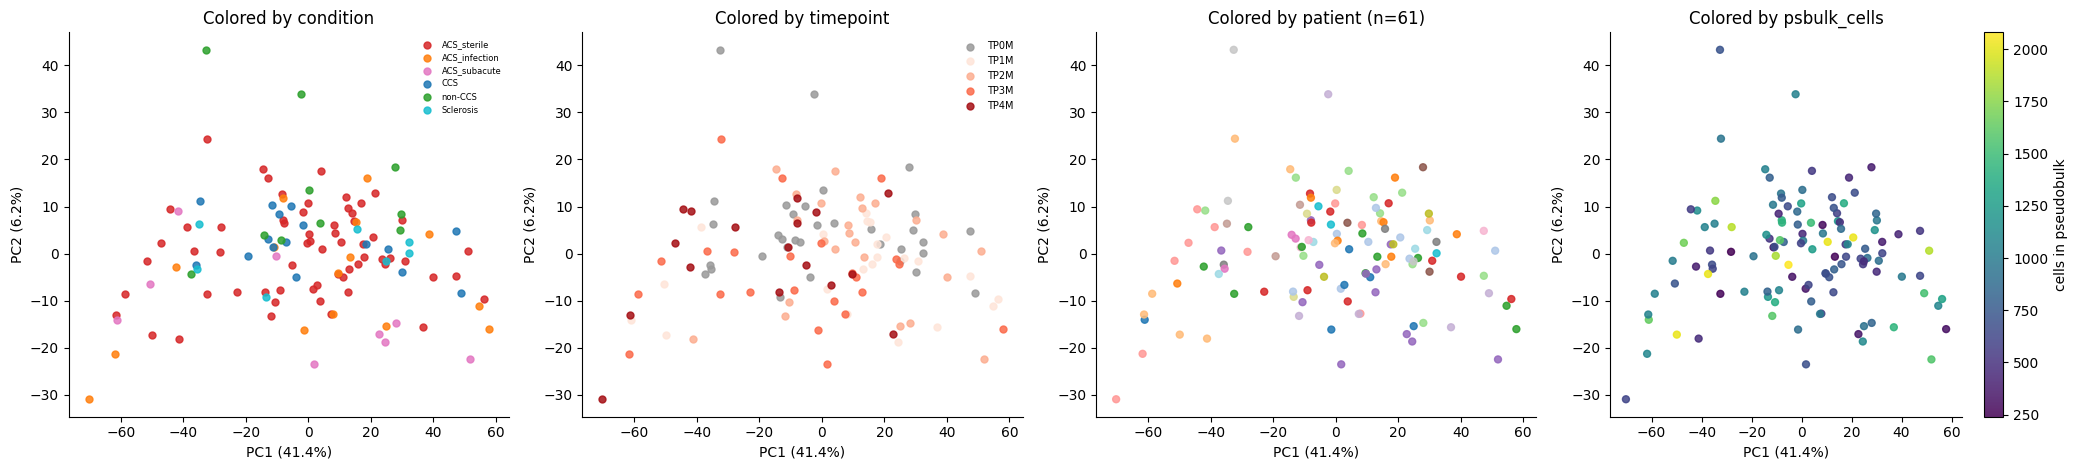

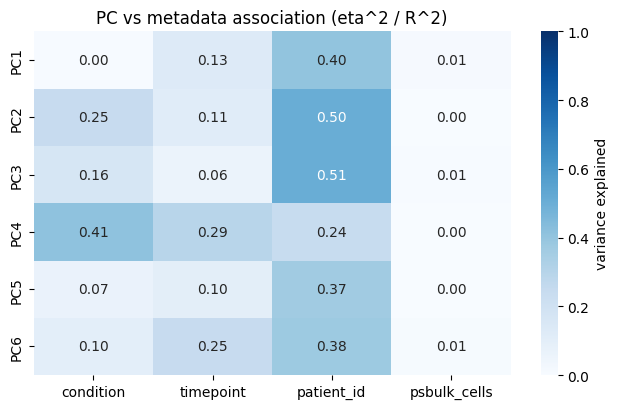

Variance explained per PC: ['41.4%', '6.2%', '5.3%', '3.0%', '2.3%', '2.1%', '1.8%', '1.6%', '1.2%', '1.1%']


In [6]:
X = adata.layers["counts"]
sample_ids = adata.obs["display_name"].values
unique_samples = adata.obs["display_name"].unique()

counts_list, meta_list = [], []
for s in unique_samples:
    idx = np.where(sample_ids == s)[0]
    X_sub = X[idx]
    summed = np.asarray(X_sub.sum(axis=0)).flatten() if issparse(X_sub) else np.asarray(X_sub.sum(axis=0)).flatten()
    counts_list.append(summed)
    row = adata.obs.iloc[idx[0]]
    meta_list.append({
        "sample": s, "condition": row["condition"], "timepoint": row["timepoint"],
        "patient_id": row["patient_id"], "psbulk_cells": len(idx),
    })

counts_mat = np.vstack(counts_list)
meta_df = pd.DataFrame(meta_list).set_index("sample")

libsize = counts_mat.sum(axis=1, keepdims=True)
cpm = counts_mat / libsize * 1e6
logcpm = np.log1p(cpm)
gene_var = logcpm.var(axis=0)
top_genes_idx = np.argsort(gene_var)[-2000:]
X_pca_input = logcpm[:, top_genes_idx]
X_pca_input = (X_pca_input - X_pca_input.mean(axis=0)) / (X_pca_input.std(axis=0) + 1e-8)

pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(X_pca_input)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 4, figsize=(21, 4.8))

ax = axes[0]
for cond in condition_order:
    m = (meta_df["condition"] == cond).values
    ax.scatter(pcs[m, 0], pcs[m, 1], color=colors_cond[cond], label=cond, s=25, alpha=0.85)
ax.set_title("Colored by condition")
ax.legend(fontsize=6, frameon=False, loc="best")

ax = axes[1]
tp_colors = {"TP0M": "#999999", "TP1M": "#fee5d9", "TP2M": "#fcae91", "TP3M": "#fb6a4a", "TP4M": "#a50f15"}
for tp in ["TP0M", "TP1M", "TP2M", "TP3M", "TP4M"]:
    m = (meta_df["timepoint"] == tp).values
    ax.scatter(pcs[m, 0], pcs[m, 1], color=tp_colors[tp], label=tp, s=25, alpha=0.85)
ax.set_title("Colored by timepoint")
ax.legend(fontsize=7, frameon=False, loc="best")

ax = axes[2]
patient_codes = meta_df["patient_id"].astype("category").cat.codes
ax.scatter(pcs[:, 0], pcs[:, 1], c=patient_codes, cmap="tab20", s=25, alpha=0.85)
ax.set_title(f"Colored by patient (n={meta_df['patient_id'].nunique()})")

ax = axes[3]
sc_ = ax.scatter(pcs[:, 0], pcs[:, 1], c=meta_df["psbulk_cells"], cmap="viridis", s=25, alpha=0.85)
plt.colorbar(sc_, ax=ax, label="cells in pseudobulk")
ax.set_title("Colored by psbulk_cells")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel5a_pseudobulk_pca.png"), bbox_inches="tight", dpi=150)
plt.show()

n_pcs_to_test = 6
covariates_cat = ["condition", "timepoint", "patient_id"]
assoc = pd.DataFrame(index=[f"PC{i+1}" for i in range(n_pcs_to_test)],
                      columns=covariates_cat + ["psbulk_cells"], dtype=float)

for i in range(n_pcs_to_test):
    y = pcs[:, i]
    for cov in covariates_cat:
        groups = [y[(meta_df[cov] == g).values] for g in meta_df[cov].unique()]
        groups = [g for g in groups if len(g) > 1]
        if len(groups) < 2:
            assoc.iloc[i, assoc.columns.get_loc(cov)] = np.nan
            continue
        ss_between = sum(len(g) * (g.mean() - y.mean()) ** 2 for g in groups)
        ss_total = ((y - y.mean()) ** 2).sum()
        assoc.iloc[i, assoc.columns.get_loc(cov)] = ss_between / ss_total if ss_total > 0 else np.nan
    r, _ = sstats.pearsonr(y, meta_df["psbulk_cells"].values)
    assoc.iloc[i, assoc.columns.get_loc("psbulk_cells")] = r ** 2

fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.heatmap(assoc.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "variance explained"}, ax=ax)
ax.set_title("PC vs metadata association (eta^2 / R^2)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel5b_pc_metadata_heatmap.png"), bbox_inches="tight", dpi=150)
plt.show()

print("Variance explained per PC:", [f"{v:.1%}" for v in var_explained])

## Panel 6 — Batch x condition crosstab

`library` (the 10x GEM well / pooling batch, L1-L14) is the only batch-like variable in this dataset — there is no separate 10x chemistry version or sequencing-run column. If library is confounded with condition, that confound cannot be separated from any DEG result.

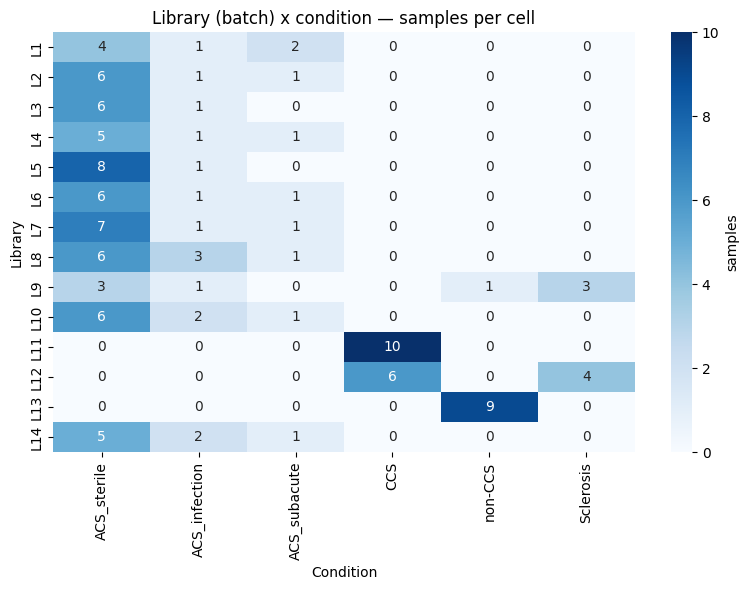

Libraries containing samples from only ONE condition (potential batch-condition confound):
['L11', 'L13']


In [7]:
batch_ct = (
    adata.obs.drop_duplicates("display_name")
    .groupby(["library", "condition"], observed=True)
    .size()
    .unstack(fill_value=0)
)
batch_ct = batch_ct.reindex(columns=[c for c in condition_order if c in batch_ct.columns])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(batch_ct, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "samples"}, ax=ax)
ax.set_title("Library (batch) x condition — samples per cell", fontsize=12)
ax.set_xlabel("Condition")
ax.set_ylabel("Library")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel6_batch_condition_crosstab.png"), bbox_inches="tight", dpi=150)
plt.show()

pure_libs = (batch_ct > 0).sum(axis=1)
confounded = pure_libs[pure_libs == 1]
print("Libraries containing samples from only ONE condition (potential batch-condition confound):")
print(confounded.index.tolist() if not confounded.empty else "None -- every library spans multiple conditions.")

## Panel 7 — Per-sample QC strip

Median genes/cell, mean %mito, and mean scDblFinder doublet score per sample, grouped by condition. Cheap check for whether an apparent ACS signal is really just lower library quality in that group. Note: `scDblFinder_class` in this dataset is 100% "singlet" (doublets were already removed upstream), so the continuous `scDblFinder_score` is used instead of a doublet rate.

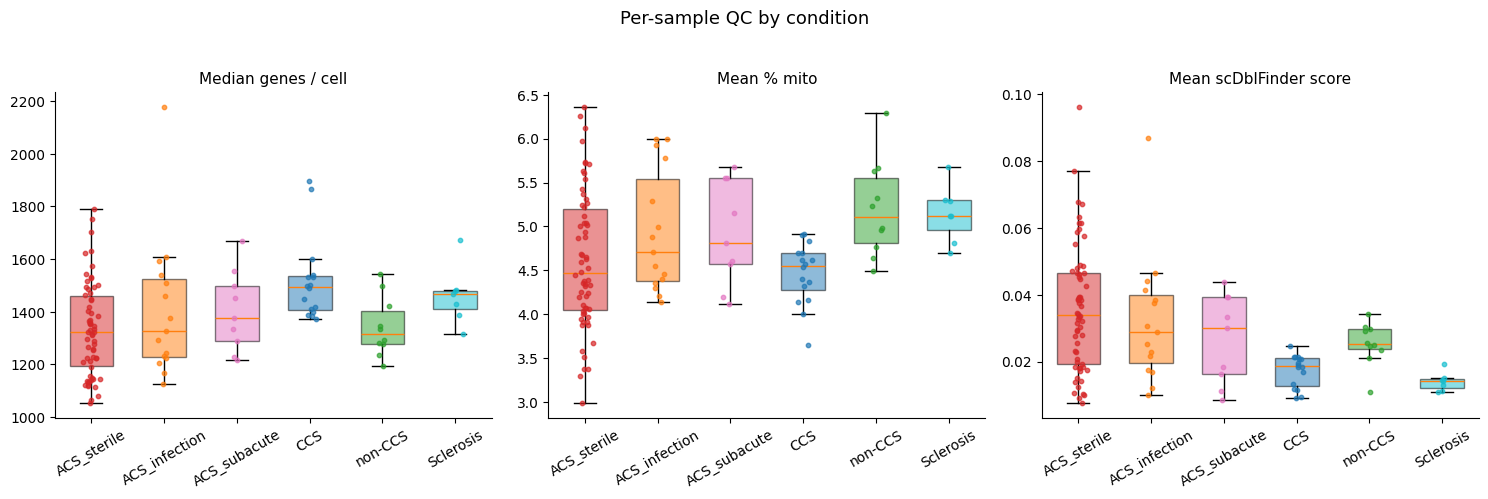

In [8]:
sample_qc = adata.obs.groupby("display_name", observed=True).agg(
    median_genes=("n_genes_by_counts", "median"),
    mean_pct_mt=("pct_counts_mt", "mean"),
    mean_dblfinder_score=("scDblFinder_score", "mean"),
    condition=("condition", "first"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, metric, title in zip(
    axes,
    ["median_genes", "mean_pct_mt", "mean_dblfinder_score"],
    ["Median genes / cell", "Mean % mito", "Mean scDblFinder score"],
):
    data = [sample_qc.loc[sample_qc["condition"] == c, metric].dropna().values for c in condition_order]
    bp = ax.boxplot(data, tick_labels=condition_order, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], condition_order):
        patch.set_facecolor(colors_cond[c])
        patch.set_alpha(0.5)
    for i, c in enumerate(condition_order):
        y = sample_qc.loc[sample_qc["condition"] == c, metric].dropna().values
        x = np.random.normal(i + 1, 0.05, size=len(y))
        ax.scatter(x, y, s=10, color=colors_cond[c], alpha=0.7, zorder=3)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Per-sample QC by condition", fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "panel7_persample_qc_strip.png"), bbox_inches="tight", dpi=150)
plt.show()

In [9]:
print("Done. Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {f}")

Done. Output files:
  panel1_patient_timepoint_matrix.png
  panel2_composition_per_sample.png
  panel4a_pseudobulk_filter_scatter.png
  panel4b_surviving_pseudobulks.png
  panel5a_pseudobulk_pca.png
  panel5b_pc_metadata_heatmap.png
  panel6_batch_condition_crosstab.png
  panel7_persample_qc_strip.png
